# Explainability

## Objective

This notebook produces SHAP-based explanations for the pooled models trained in Notebook 09 and saves the raw artifacts consumed by Notebook 14 (Explanation Stability).

The notebook does **not** judge stability. It computes and saves:

- Global SHAP importance per model (pooled, 2025 test set)
- Per-stock rankings (pooled model sliced by ticker)
- Per-period rankings (2025 split into halves)
- Correct vs incorrect vs high-confidence-incorrect subsets
- Local explanations for representative cases
- Multi-seed SHAP arrays for the across-runs stability metric in Notebook 14

## Scope

SHAP is computed for **Random Forest**, **XGBoost**, and **L2 Logistic Regression**. LSTM SHAP is left as an optional appendix because `GradientExplainer` on Keras sequences is noisier and materially slower.

## Research role

Notebook 13 addresses the compute side of RQ4 (feature-explanation stability) and the Supporting Analysis box (correct vs incorrect vs high-confidence-incorrect explanations). The comparison metrics themselves live in Notebook 14.

## Imports

In [1]:
# ==========================================================
# Imports
# ==========================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
import shap

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
TEST_YEAR = 2025

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Imports completed.")
print("SHAP version:", shap.__version__)

Imports completed.
SHAP version: 0.51.0


## Load Model-Ready Dataset

The same dataset, feature list, and 2020–2024 / 2025 split as Notebook 09 are used so that the SHAP values correspond exactly to the model inputs seen at training time.

In [2]:
# ==========================================================
# Load Model-Ready Dataset
# ==========================================================

DATA_PATH = (
    "/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/model_ready_complete_case_2020_2025.csv"
)

data_df = pd.read_csv(DATA_PATH)
data_df["date"] = pd.to_datetime(data_df["date"])

data_df["gdelt_tone_missing"] = (
    data_df["gdelt_company_tone"].isna().astype(int)
)
data_df["gdelt_company_tone"] = (
    data_df["gdelt_company_tone"].fillna(0)
)

print(f"Dataset shape: {data_df.shape}")
print(f"Date range   : {data_df['date'].min()} to {data_df['date'].max()}")

Dataset shape: (7370, 42)
Date range   : 2020-01-13 00:00:00 to 2025-12-22 00:00:00


In [3]:
# ==========================================================
# Feature Selection (matches Notebook 09)
# ==========================================================

TARGET = "target_5d"

DROP_COLUMNS = [
    "ticker", "date",
    "future_close_5d", "forward_return_5d",
    "movement_5d", "target_5d",
    "Dividends", "Stock Splits",
    "daily_return_check",
]

FEATURE_COLUMNS = [
    c for c in data_df.columns if c not in DROP_COLUMNS
]

CLASS_NAMES = ["Down", "Neutral", "Up"]

print(f"Predictor features: {len(FEATURE_COLUMNS)}")
print(FEATURE_COLUMNS)

Predictor features: 33
['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_50', 'SMA_200', 'EMA_50', 'EMA_200', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'ATR', 'ADX', 'gdelt_company_tone', 'gdelt_tone_missing', 'gdelt_tone_lag_1', 'gdelt_tone_mean_3', 'gdelt_tone_mean_5', 'gdelt_tone_std_5', 'gdelt_tone_change_1d', 'gdelt_abnormal_tone_20', 'market_close', 'market_return', 'vix_close', 'vix_change', 'market_return_lag_1', 'vix_close_lag_1', 'vix_change_lag_1']


In [4]:
# ==========================================================
# Temporal Train/Test Split (matches Notebook 09)
# ==========================================================

train_df = (
    data_df[data_df["date"].dt.year < TEST_YEAR]
    .sort_values(["ticker", "date"])
    .copy()
)

test_df = (
    data_df[data_df["date"].dt.year == TEST_YEAR]
    .sort_values(["ticker", "date"])
    .copy()
)

x_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET]
x_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET]

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

stocks = sorted(data_df["ticker"].unique())

print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")
print(f"Stocks: {stocks}")

Train: 6,240 | Test: 1,130
Stocks: ['BRK-B', 'CVX', 'GE', 'MSFT', 'NVDA']


## Load Pooled Models from Notebook 09

The Random Forest, XGBoost, and Logistic Regression models saved at the end of Notebook 09 are loaded. The `StandardScaler` above was refit on identical training data so that the LR inputs to SHAP match how the model was trained.

In [5]:
# ==========================================================
# Load Pooled Models
# ==========================================================

MODEL_DIR = (
    "/kaggle/input/notebooks/phyothaw/09-pooled-global-model-ipynb"
)

rf_model = joblib.load(f"{MODEL_DIR}/random_forest_model.joblib")
xgb_model = joblib.load(f"{MODEL_DIR}/xgboost_model.joblib")
lr_model = joblib.load(f"{MODEL_DIR}/logistic_regression_model.joblib")

MODELS = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Logistic Regression": lr_model,
}

print("Loaded:", list(MODELS.keys()))

Loaded: ['Random Forest', 'XGBoost', 'Logistic Regression']


## SHAP Helper Functions

For multi-class models, SHAP returns per-class arrays. The `_stack_multiclass` helper normalises them into a single 3-D array of shape `(n_samples, n_features, n_classes)` so that downstream aggregations are consistent across model types.

`mean_abs_shap` collapses across classes (`mean(|SHAP|)`) to produce a single global ranking; per-class rankings are also retained.

In [6]:
# ==========================================================
# SHAP Helpers
# ==========================================================

def _stack_multiclass(shap_output, n_classes=3):
    """
    Normalise SHAP output to shape (n_samples, n_features, n_classes).
    Handles list-of-arrays (sklearn tree/linear) and 3D arrays (xgboost).
    """
    if isinstance(shap_output, list):
        return np.stack(shap_output, axis=-1)
    arr = np.asarray(shap_output)
    if arr.ndim == 3:
        return arr
    raise ValueError(f"Unexpected SHAP shape: {arr.shape}")


def mean_abs_shap(shap_3d, feature_names):
    """
    Collapse SHAP (n, f, c) to per-feature mean(|shap|) averaged across
    samples and classes. Returns a Series indexed by feature name.
    """
    per_feature = np.abs(shap_3d).mean(axis=(0, 2))
    return pd.Series(per_feature, index=feature_names)


def per_class_mean_abs(shap_3d, feature_names, class_names):
    """Return a DataFrame: feature x class of mean(|shap|)."""
    per = np.abs(shap_3d).mean(axis=0)  # (f, c)
    return pd.DataFrame(per, index=feature_names, columns=class_names)


def compute_shap(model_name, model, background, x_explain):
    """
    Return SHAP values shaped (n_samples, n_features, n_classes).

    - RF/XGB use TreeExplainer
    - Logistic Regression uses LinearExplainer with a masked background
    """
    if model_name in ("Random Forest", "XGBoost"):
        explainer = shap.TreeExplainer(model)
        raw = explainer.shap_values(x_explain)
    elif model_name == "Logistic Regression":
        explainer = shap.LinearExplainer(model, background)
        raw = explainer.shap_values(x_explain)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return _stack_multiclass(raw), explainer

## Global SHAP per Model (Pooled, 2025 test set)

In [7]:
# ==========================================================
# Compute SHAP for each pooled model on the 2025 test set
# ==========================================================

shap_arrays = {}
explainers = {}

# Random Forest and XGBoost use raw (unscaled) inputs
shap_arrays["Random Forest"], explainers["Random Forest"] = compute_shap(
    "Random Forest", rf_model, x_train.values, x_test.values
)
shap_arrays["XGBoost"], explainers["XGBoost"] = compute_shap(
    "XGBoost", xgb_model, x_train.values, x_test.values
)

# Logistic Regression uses scaled inputs
shap_arrays["Logistic Regression"], explainers["Logistic Regression"] = compute_shap(
    "Logistic Regression", lr_model, x_train_scaled, x_test_scaled
)

for name, arr in shap_arrays.items():
    print(f"{name:20s} SHAP shape: {arr.shape}")

Random Forest        SHAP shape: (1130, 33, 3)
XGBoost              SHAP shape: (1130, 33, 3)
Logistic Regression  SHAP shape: (1130, 33, 3)


In [8]:
# ==========================================================
# Global mean(|SHAP|) rankings
# ==========================================================

global_rows = []

for model_name, shap_3d in shap_arrays.items():
    ranking = (
        mean_abs_shap(shap_3d, FEATURE_COLUMNS)
        .sort_values(ascending=False)
    )
    for rank, (feature, value) in enumerate(ranking.items(), start=1):
        global_rows.append({
            "model": model_name,
            "feature": feature,
            "mean_abs_shap": value,
            "rank": rank,
        })

shap_global_df = pd.DataFrame(global_rows)

display(
    shap_global_df
    .sort_values(["model", "rank"])
    .groupby("model")
    .head(10)
    .reset_index(drop=True)
)

,model,feature,mean_abs_shap,rank
0,Logistic Regression,BB_Upper,0.6103,1
1,Logistic Regression,SMA_200,0.5636,2
2,Logistic Regression,EMA_200,0.5135,3
3,Logistic Regression,SMA_50,0.4112,4
4,Logistic Regression,BB_Middle,0.3457,5
5,Logistic Regression,Open,0.3329,6
6,Logistic Regression,Close,0.2911,7
7,Logistic Regression,ATR,0.2394,8
8,Logistic Regression,BB_Lower,0.1695,9
9,Logistic Regression,EMA_50,0.1555,10


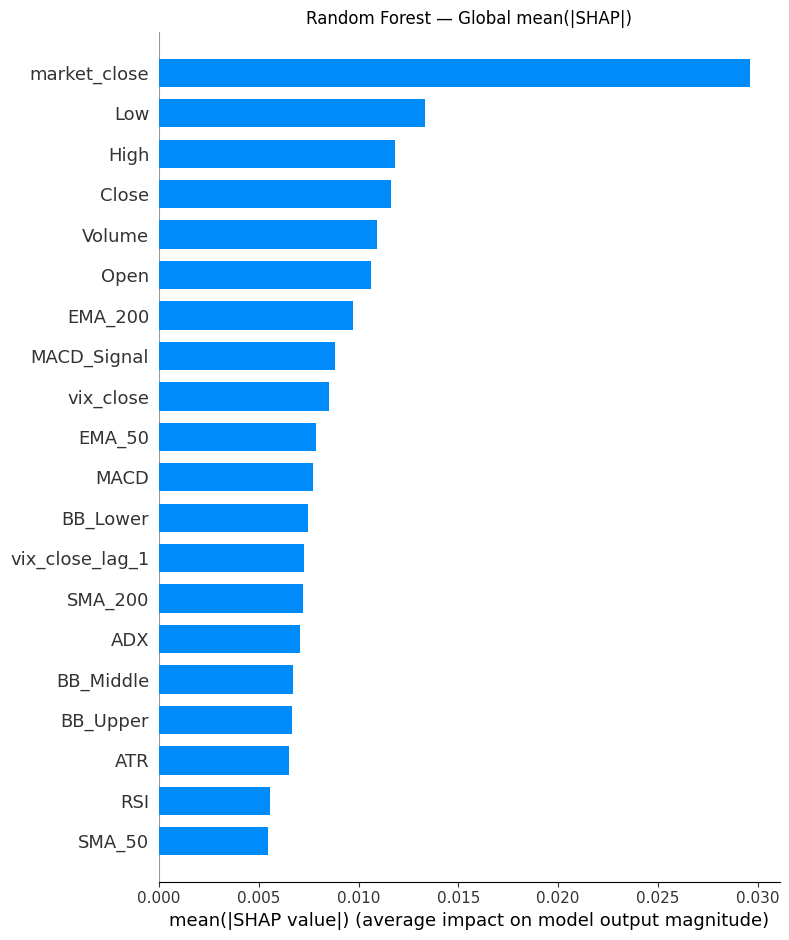

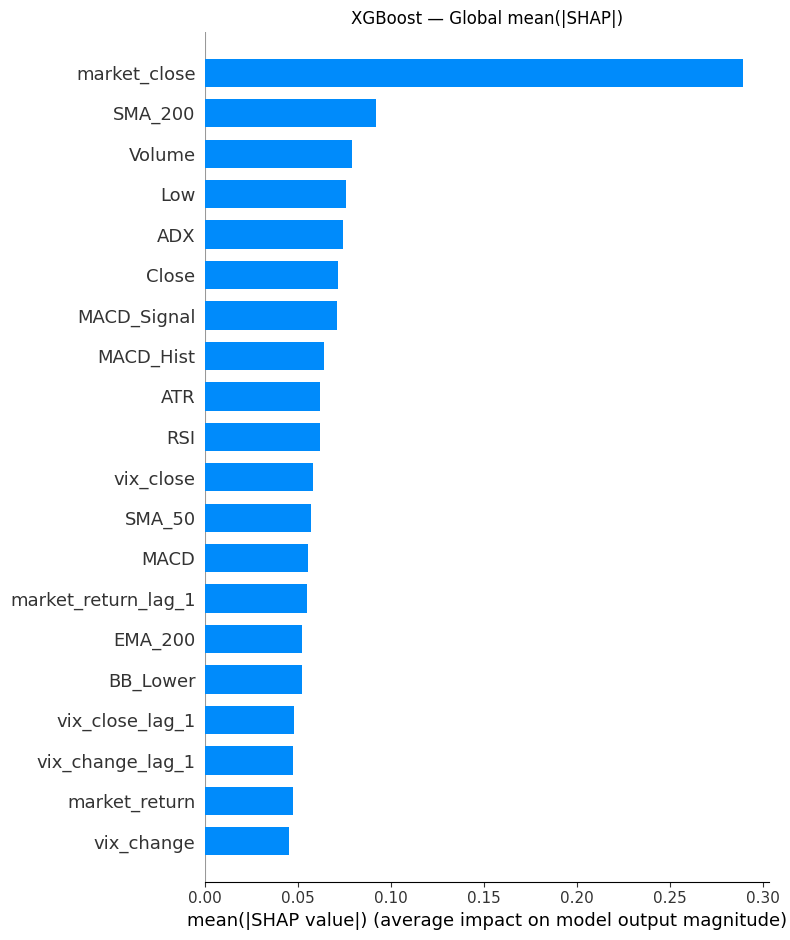

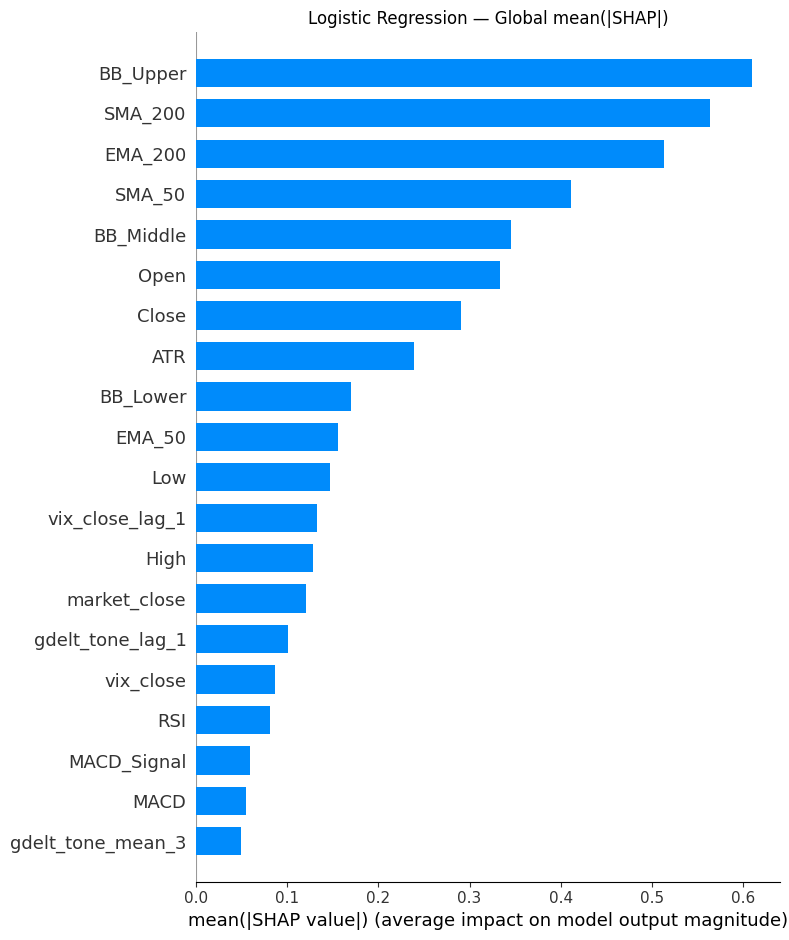

In [9]:
# ==========================================================
# Global summary plots per model
# ==========================================================

for model_name, shap_3d in shap_arrays.items():
    x_for_plot = (
        x_test_scaled if model_name == "Logistic Regression" else x_test.values
    )

    # Aggregate across classes for a single bar summary
    mean_over_classes = np.abs(shap_3d).mean(axis=2)  # (n, f)

    plt.figure()
    shap.summary_plot(
        mean_over_classes,
        features=x_for_plot,
        feature_names=FEATURE_COLUMNS,
        plot_type="bar",
        show=False,
    )
    plt.title(f"{model_name} — Global mean(|SHAP|)")
    plt.tight_layout()
    plt.show()

## Per-Stock Rankings

The pooled SHAP values are sliced by ticker to produce a `feature × ticker × model` importance table. This is the primary input to the across-stocks stability metric in Notebook 14.

In [10]:
# ==========================================================
# Per-stock rankings from pooled SHAP
# ==========================================================

ticker_arr = test_df["ticker"].values

per_stock_rows = []

for model_name, shap_3d in shap_arrays.items():
    for stock in stocks:
        mask = ticker_arr == stock
        stock_shap = shap_3d[mask]

        ranking = (
            mean_abs_shap(stock_shap, FEATURE_COLUMNS)
            .sort_values(ascending=False)
        )

        for rank, (feature, value) in enumerate(ranking.items(), start=1):
            per_stock_rows.append({
                "model": model_name,
                "ticker": stock,
                "feature": feature,
                "mean_abs_shap": value,
                "rank": rank,
            })

shap_per_stock_df = pd.DataFrame(per_stock_rows)

print("Top-5 features per stock (Random Forest):")
display(
    shap_per_stock_df
    .query("model == 'Random Forest' and rank <= 5")
    .pivot(index="rank", columns="ticker", values="feature")
)

Top-5 features per stock (Random Forest):


ticker,BRK-B,CVX,GE,MSFT,NVDA
rank,,,,,
1,High,market_close,market_close,Low,market_close
2,Low,BB_Lower,Volume,High,Volume
3,market_close,EMA_200,MACD,Open,Close
4,Open,Low,MACD_Signal,market_close,Low
5,Close,SMA_200,vix_close,Close,SMA_200


## Per-Period Rankings

The 2025 test period is split into two halves. This feeds the across-time stability dimension in Notebook 14. Quarterly splitting is also supported by changing `N_PERIODS`.

In [11]:
# ==========================================================
# Per-period rankings from pooled SHAP
# ==========================================================

N_PERIODS = 2  # halves; set to 4 for quarters

test_dates = pd.to_datetime(test_df["date"].values)
period_labels = pd.qcut(
    test_dates.astype(np.int64),
    q=N_PERIODS,
    labels=[f"P{i+1}" for i in range(N_PERIODS)],
).astype(str)

per_period_rows = []

for model_name, shap_3d in shap_arrays.items():
    for period in np.unique(period_labels):
        mask = period_labels == period
        period_shap = shap_3d[mask]

        ranking = (
            mean_abs_shap(period_shap, FEATURE_COLUMNS)
            .sort_values(ascending=False)
        )

        for rank, (feature, value) in enumerate(ranking.items(), start=1):
            per_period_rows.append({
                "model": model_name,
                "period": period,
                "feature": feature,
                "mean_abs_shap": value,
                "rank": rank,
            })

shap_per_period_df = pd.DataFrame(per_period_rows)

print(f"Periods used: {sorted(set(period_labels))}")
print(f"Rows: {len(shap_per_period_df):,}")

Periods used: [np.str_('P1'), np.str_('P2')]
Rows: 198


## Correct vs Incorrect vs High-Confidence-Incorrect

The pooled predictions from Notebook 09 are joined to the SHAP values so that samples can be labelled as `correct`, `incorrect`, or `incorrect_high_conf` (max predicted probability > 0.7 and wrong class).

In [12]:
# ==========================================================
# Load pooled predictions from Notebook 09
# ==========================================================

PRED_PATH = (
    "/kaggle/input/notebooks/phyothaw/"
    "09-pooled-global-model-ipynb/"
    "pooled_model_predictions.csv"
)

pred_df = pd.read_csv(PRED_PATH)
pred_df["date"] = pd.to_datetime(pred_df["date"])

pred_df["max_prob"] = pred_df[
    ["prob_down", "prob_neutral", "prob_up"]
].max(axis=1)
pred_df["is_correct"] = pred_df["predicted"] == pred_df["actual"]

HIGH_CONF_THRESHOLD = 0.7

def outcome_bucket(row):
    if row["is_correct"]:
        return "correct"
    if row["max_prob"] > HIGH_CONF_THRESHOLD:
        return "incorrect_high_conf"
    return "incorrect"

pred_df["outcome"] = pred_df.apply(outcome_bucket, axis=1)

print("Outcome counts by model:")
display(
    pred_df.groupby(["model", "outcome"]).size().unstack(fill_value=0)
)

Outcome counts by model:


outcome,correct,incorrect,incorrect_high_conf
model,,,
Dummy Classifier,424,0,706
LSTM,438,692,0
Logistic Regression,438,692,0
Random Forest,399,716,15
XGBoost,381,550,199


In [13]:
# ==========================================================
# Mean(|SHAP|) per feature per outcome bucket
# ==========================================================

# test_df is aligned row-wise with the SHAP arrays.
# Join predictions on (ticker, date, model) to get per-row outcome.

test_keys = test_df[["ticker", "date"]].reset_index(drop=True)
test_keys["row_idx"] = np.arange(len(test_keys))

outcome_rows = []

for model_name, shap_3d in shap_arrays.items():
    model_pred = pred_df[pred_df["model"] == model_name]

    merged = test_keys.merge(
        model_pred[["ticker", "date", "outcome"]],
        on=["ticker", "date"],
        how="left",
    )

    for bucket in ["correct", "incorrect", "incorrect_high_conf"]:
        idx = merged.loc[merged["outcome"] == bucket, "row_idx"].values
        if len(idx) == 0:
            continue

        subset = shap_3d[idx]
        ranking = (
            mean_abs_shap(subset, FEATURE_COLUMNS)
            .sort_values(ascending=False)
        )

        for rank, (feature, value) in enumerate(ranking.items(), start=1):
            outcome_rows.append({
                "model": model_name,
                "outcome": bucket,
                "n_samples": len(idx),
                "feature": feature,
                "mean_abs_shap": value,
                "rank": rank,
            })

shap_by_outcome_df = pd.DataFrame(outcome_rows)

print("Rows:", len(shap_by_outcome_df))

Rows: 264


## Local Explanations

Six representative cases are chosen for the Random Forest pooled model: two tickers × `{correct, incorrect, high-conf-incorrect}`. Waterfall plots are saved as PNGs and metadata is recorded in `local_cases.csv`.

In [14]:
# ==========================================================
# Select local cases
# ==========================================================

LOCAL_MODEL = "Random Forest"
LOCAL_TICKERS = ["NVDA", "MSFT"]

local_model_pred = (
    pred_df[pred_df["model"] == LOCAL_MODEL]
    .copy()
)

cases = []

for ticker in LOCAL_TICKERS:
    subset = local_model_pred[local_model_pred["ticker"] == ticker]

    for bucket in ["correct", "incorrect", "incorrect_high_conf"]:
        cand = subset[subset["outcome"] == bucket]
        if cand.empty:
            continue

        # For each bucket pick the highest-confidence example
        pick = cand.sort_values("max_prob", ascending=False).iloc[0]
        cases.append({
            "ticker": ticker,
            "date": pick["date"],
            "outcome": bucket,
            "actual": int(pick["actual"]),
            "predicted": int(pick["predicted"]),
            "max_prob": float(pick["max_prob"]),
        })

local_cases_df = pd.DataFrame(cases)
display(local_cases_df)

,ticker,date,outcome,actual,predicted,max_prob
0,NVDA,2025-04-23,correct,2,2,0.7633
1,NVDA,2025-03-05,incorrect,1,2,0.6867
2,NVDA,2025-01-02,incorrect_high_conf,0,2,0.7633
3,MSFT,2025-03-13,correct,2,2,0.6900
4,MSFT,2025-06-12,incorrect,1,0,0.7000
5,MSFT,2025-07-18,incorrect_high_conf,1,0,0.7200


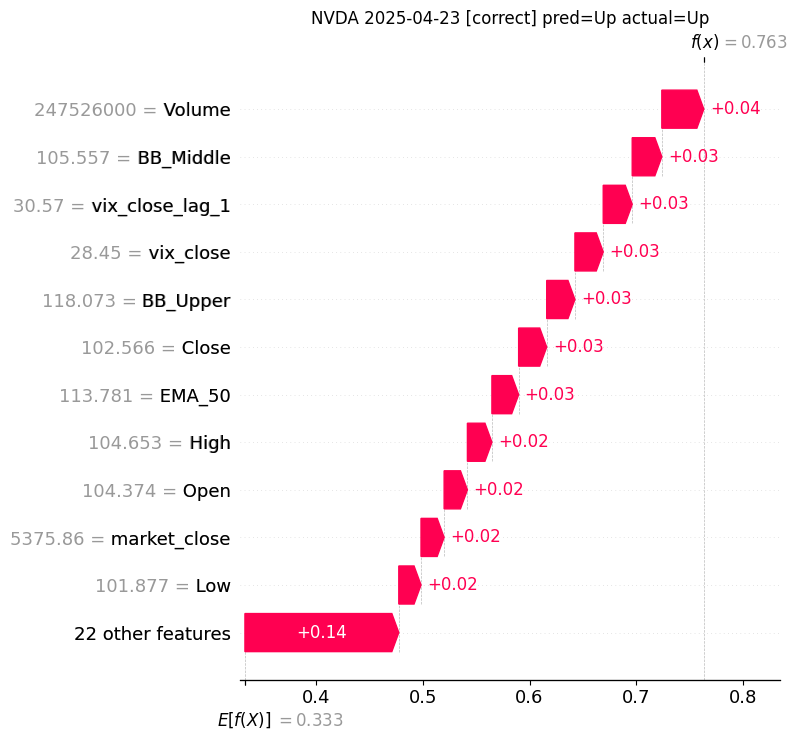

Saved: /kaggle/working/local_NVDA_2025-04-23_correct.png


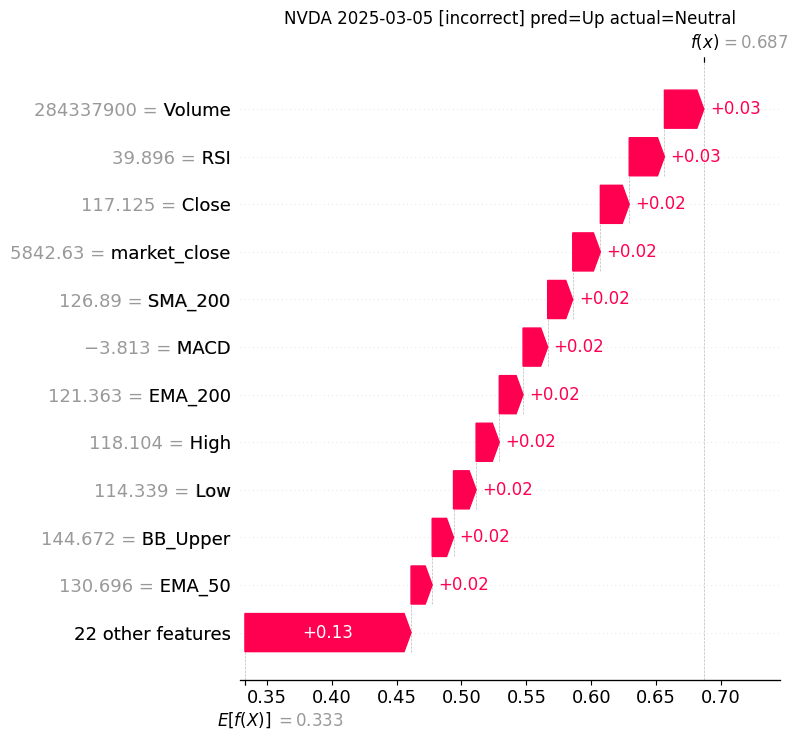

Saved: /kaggle/working/local_NVDA_2025-03-05_incorrect.png


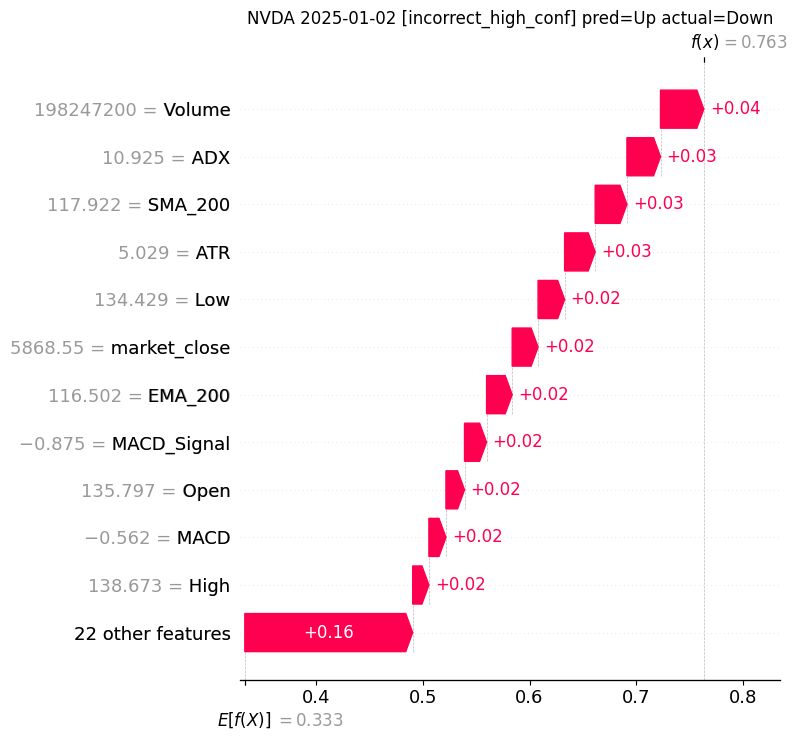

Saved: /kaggle/working/local_NVDA_2025-01-02_incorrect_high_conf.png


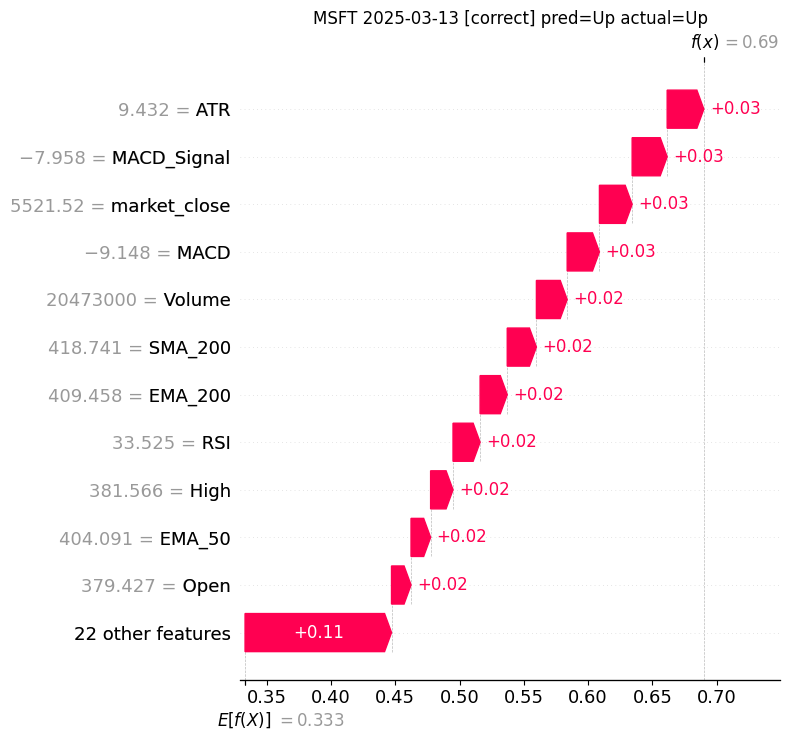

Saved: /kaggle/working/local_MSFT_2025-03-13_correct.png


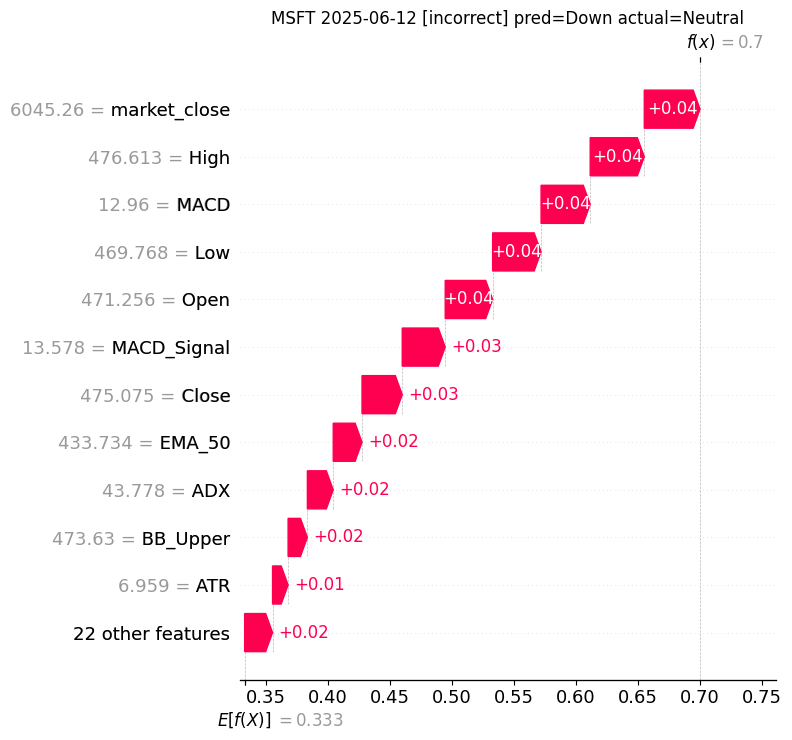

Saved: /kaggle/working/local_MSFT_2025-06-12_incorrect.png


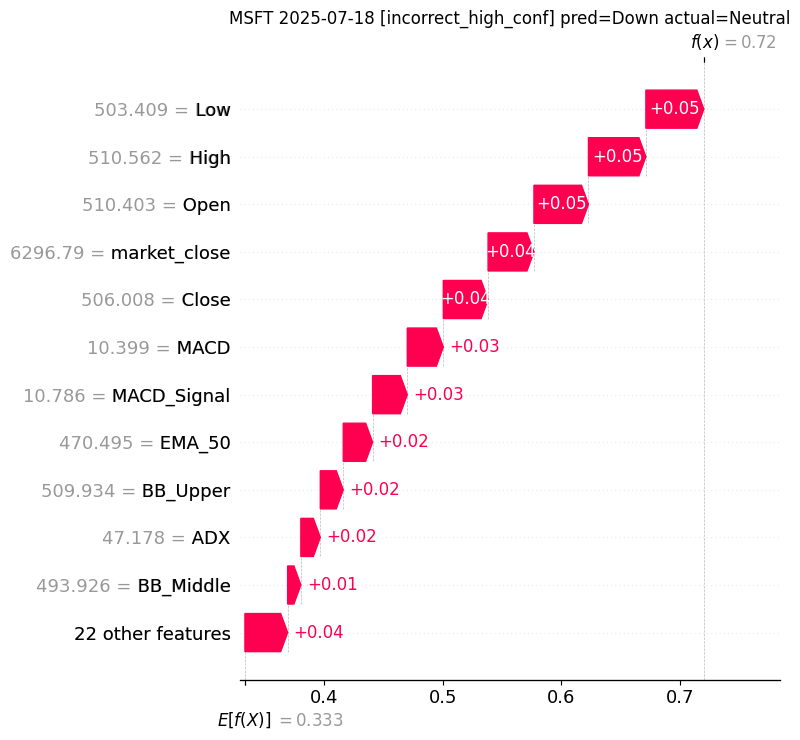

Saved: /kaggle/working/local_MSFT_2025-07-18_incorrect_high_conf.png


In [15]:
# ==========================================================
# Waterfall plots for local cases
# ==========================================================

rf_shap = shap_arrays[LOCAL_MODEL]
rf_explainer = explainers[LOCAL_MODEL]

# Base values: TreeExplainer returns list of length n_classes for RF
base_values = rf_explainer.expected_value
if isinstance(base_values, (list, np.ndarray)):
    base_values = np.asarray(base_values)
else:
    base_values = np.array([base_values])

for case in cases:
    match = test_keys[
        (test_keys["ticker"] == case["ticker"])
        & (test_keys["date"] == case["date"])
    ]
    if match.empty:
        continue

    row_idx = int(match["row_idx"].iloc[0])
    predicted_class = case["predicted"]

    explanation = shap.Explanation(
        values=rf_shap[row_idx, :, predicted_class],
        base_values=base_values[predicted_class]
            if base_values.ndim > 0 else float(base_values),
        data=x_test.iloc[row_idx].values,
        feature_names=FEATURE_COLUMNS,
    )

    plt.figure()
    shap.plots.waterfall(explanation, max_display=12, show=False)
    title = (
        f"{case['ticker']} {pd.to_datetime(case['date']).date()} "
        f"[{case['outcome']}] pred={CLASS_NAMES[case['predicted']]} "
        f"actual={CLASS_NAMES[case['actual']]}"
    )
    plt.title(title)
    fname = (
        f"{OUTPUT_DIR}/local_{case['ticker']}_"
        f"{pd.to_datetime(case['date']).date()}_{case['outcome']}.png"
    )
    plt.tight_layout()
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved:", fname)

## Multi-Seed SHAP Arrays

Random Forest and XGBoost are retrained with several `RANDOM_STATE` values. The full SHAP array from each seed is saved so that Notebook 14 can compute mean `|ΔSHAP|` and direction consistency across runs.

Logistic Regression is deterministic and adds no useful across-runs signal — it is intentionally excluded here. If you want it later, set `INCLUDE_LR_SEEDS = True`.

In [16]:
# ==========================================================
# Multi-seed retraining and SHAP
# ==========================================================

SEEDS = [0, 1, 2, 3, 4]
INCLUDE_LR_SEEDS = False

seed_shap = {"Random Forest": {}, "XGBoost": {}}

for seed in SEEDS:
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=seed,
        class_weight="balanced",
        n_jobs=-1,
    )
    rf.fit(x_train, y_train)
    rf_shap_seed, _ = compute_shap("Random Forest", rf, x_train.values, x_test.values)
    seed_shap["Random Forest"][seed] = rf_shap_seed

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=seed,
        n_jobs=-1,
    )
    xgb.fit(x_train, y_train)
    xgb_shap_seed, _ = compute_shap("XGBoost", xgb, x_train.values, x_test.values)
    seed_shap["XGBoost"][seed] = xgb_shap_seed

    print(f"Seed {seed} — RF and XGB SHAP computed")

for model_name, seeds_dict in seed_shap.items():
    for seed, arr in seeds_dict.items():
        safe = model_name.lower().replace(" ", "_")
        np.savez_compressed(
            f"{OUTPUT_DIR}/shap_values_{safe}_seed{seed}.npz",
            shap_values=arr,
        )

print("Multi-seed SHAP arrays saved.")

Seed 0 — RF and XGB SHAP computed
Seed 1 — RF and XGB SHAP computed
Seed 2 — RF and XGB SHAP computed
Seed 3 — RF and XGB SHAP computed
Seed 4 — RF and XGB SHAP computed
Multi-seed SHAP arrays saved.


## Save All Artifacts

In [17]:
# ==========================================================
# Save CSV artifacts and pooled SHAP arrays
# ==========================================================

shap_global_df.to_csv(f"{OUTPUT_DIR}/shap_global.csv", index=False)
shap_per_stock_df.to_csv(f"{OUTPUT_DIR}/shap_per_stock.csv", index=False)
shap_per_period_df.to_csv(f"{OUTPUT_DIR}/shap_per_period.csv", index=False)
shap_by_outcome_df.to_csv(f"{OUTPUT_DIR}/shap_by_outcome.csv", index=False)
local_cases_df.to_csv(f"{OUTPUT_DIR}/local_cases.csv", index=False)

# Pooled SHAP arrays (single seed = 42), aligned with test_df row order
for model_name, arr in shap_arrays.items():
    safe = model_name.lower().replace(" ", "_")
    np.savez_compressed(
        f"{OUTPUT_DIR}/shap_values_pooled_{safe}.npz",
        shap_values=arr,
    )

# Row-order index so Notebook 14 can align SHAP arrays to (ticker, date)
test_keys.to_csv(f"{OUTPUT_DIR}/shap_row_index.csv", index=False)

# Feature order + class name reference
with open(f"{OUTPUT_DIR}/shap_metadata.json", "w") as f:
    json.dump(
        {
            "feature_columns": FEATURE_COLUMNS,
            "class_names": CLASS_NAMES,
            "test_year": TEST_YEAR,
            "seeds": SEEDS,
            "high_conf_threshold": HIGH_CONF_THRESHOLD,
        },
        f,
        indent=2,
    )

print("Saved artifacts to", OUTPUT_DIR)

Saved artifacts to /kaggle/working
